# GrowthFlow Customer Retention Strategy Optimization

# Week 3

## Day 2 – Data Loading & Quality Check

**Objective:**
Load the five datasets, inspect their structure, and assess their initial data quality before further analysis.

## 2.1 Import Required Libraries

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import sqlite3

## 2.2 Load the Datasets

In [2]:
# Read the GrowthFlow datasets into pandas DataFrames

customer_info = pd.read_csv("growthflow_customer_information.csv")
monthly_status = pd.read_csv("growthflow_monthly_status.csv")
usage_data = pd.read_csv("growthflow_usage_data.csv")
engagement_data = pd.read_csv("growthflow_engagement_data.csv")
feedback_data = pd.read_csv("growthflow_feedback_data.csv")


# Store the datasets in a dictionary for easier access and iteration

datasets = {
    "Customer Information": customer_info,
    "Monthly Status": monthly_status,
    "Usage Data": usage_data,
    "Engagement Data": engagement_data,
    "Feedback Data": feedback_data
}

## 2.3 Initial Data Inspection
This section provides an initial inspection of each dataset by reviewing sample records, dataset dimensions, column names, and data types to verify that the data has been loaded correctly and is ready for further analysis.

In [3]:
# Display the first five rows of each dataset

for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    display(df.head(5))


Customer Information


,customer_id,subscription_date,cohort,industry,region,customer_type,plan_type,company_size
0,CUST_00001,2024-04-12,2024-04-01,Finance,Europe,Mid-market,Basic,171
1,CUST_00002,2025-04-11,2025-04-01,Finance,Europe,SMB,Basic,24
2,CUST_00003,2024-05-10,2024-05-01,Education,Latin America,SMB,Enterprise,2
3,CUST_00004,2024-07-10,2024-07-01,Technology,Europe,Enterprise,Enterprise,3404
4,CUST_00005,2025-07-14,2025-07-01,Education,Latin America,SMB,Basic,15



Monthly Status


,customer_id,cohort,activity_month,months_since_sub,is_active,monthly_revenue,customer_type,plan_type,region,industry
0,CUST_00001,2024-04-01,2024-04-01,0,1,49,Mid-market,Basic,Europe,Finance
1,CUST_00001,2024-04-01,2024-05-01,1,1,49,Mid-market,Basic,Europe,Finance
2,CUST_00001,2024-04-01,2024-06-01,2,1,49,Mid-market,Basic,Europe,Finance
3,CUST_00001,2024-04-01,2024-07-01,3,1,49,Mid-market,Basic,Europe,Finance
4,CUST_00001,2024-04-01,2024-08-01,4,1,49,Mid-market,Basic,Europe,Finance



Usage Data


,customer_id,activity_month,months_since_sub,session_duration,feature_crm,feature_email_campaigns,feature_analytics,feature_automation,feature_advanced_analytics,feature_custom_workflows
0,CUST_00001,2024-04-01,0,23,1,0,1,1,0,0
1,CUST_00001,2024-05-01,1,31,1,3,1,0,0,0
2,CUST_00001,2024-06-01,2,31,2,2,1,1,0,0
3,CUST_00001,2024-07-01,3,41,1,1,1,1,0,0
4,CUST_00001,2024-08-01,4,63,1,0,1,0,0,0



Engagement Data


,customer_id,engagement_month,engagement_count,response_rate,avg_response_rate
0,CUST_00001,2024-12-01,1,1.0,0.55
1,CUST_00001,2025-01-01,1,0.0,0.55
2,CUST_00001,2025-02-01,1,1.0,0.55
3,CUST_00001,2025-03-01,1,1.0,0.61
4,CUST_00001,2025-05-01,1,0.0,0.55



Feedback Data


,customer_id,feedback_month,satisfaction_score,nps_score,feedback_category
0,CUST_00003,2024-10-01,7,30,Product
1,CUST_00003,2024-08-01,7,28,Features
2,CUST_00008,2025-11-01,9,33,Product
3,CUST_00009,2025-06-01,8,34,Features
4,CUST_00012,2025-07-01,7,34,Product


In [4]:
# Display the number of rows and columns in each dataset

for name, df in datasets.items():
    rows, columns = df.shape

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(f"Rows: {rows}")
    print(f"Columns: {columns}")


Customer Information
Rows: 5000
Columns: 8

Monthly Status
Rows: 54021
Columns: 10

Usage Data
Rows: 54021
Columns: 10

Engagement Data
Rows: 14532
Columns: 5

Feedback Data
Rows: 1447
Columns: 5


In [5]:
# Display the column names in each dataset

for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(df.columns.tolist())


Customer Information
['customer_id', 'subscription_date', 'cohort', 'industry', 'region', 'customer_type', 'plan_type', 'company_size']

Monthly Status
['customer_id', 'cohort', 'activity_month', 'months_since_sub', 'is_active', 'monthly_revenue', 'customer_type', 'plan_type', 'region', 'industry']

Usage Data
['customer_id', 'activity_month', 'months_since_sub', 'session_duration', 'feature_crm', 'feature_email_campaigns', 'feature_analytics', 'feature_automation', 'feature_advanced_analytics', 'feature_custom_workflows']

Engagement Data
['customer_id', 'engagement_month', 'engagement_count', 'response_rate', 'avg_response_rate']

Feedback Data
['customer_id', 'feedback_month', 'satisfaction_score', 'nps_score', 'feedback_category']


In [6]:
# Display the structure and data types of each dataset

for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    df.info()


Customer Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5000 non-null   object
 1   subscription_date  5000 non-null   object
 2   cohort             5000 non-null   object
 3   industry           5000 non-null   object
 4   region             5000 non-null   object
 5   customer_type      5000 non-null   object
 6   plan_type          5000 non-null   object
 7   company_size       5000 non-null   int64 
dtypes: int64(1), object(7)
memory usage: 312.6+ KB

Monthly Status
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54021 entries, 0 to 54020
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       54021 non-null  object
 1   cohort            54021 non-null  object
 2   activity_month    54021 non-null  ob

## 2.4 Data Quality Assessment
This section assesses the datasets for missing values and duplicate records that could affect the accuracy and reliability of the analysis.

In [7]:
# Check for missing values in each dataset

for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(df.isnull().sum())


Customer Information
customer_id          0
subscription_date    0
cohort               0
industry             0
region               0
customer_type        0
plan_type            0
company_size         0
dtype: int64

Monthly Status
customer_id         0
cohort              0
activity_month      0
months_since_sub    0
is_active           0
monthly_revenue     0
customer_type       0
plan_type           0
region              0
industry            0
dtype: int64

Usage Data
customer_id                   0
activity_month                0
months_since_sub              0
session_duration              0
feature_crm                   0
feature_email_campaigns       0
feature_analytics             0
feature_automation            0
feature_advanced_analytics    0
feature_custom_workflows      0
dtype: int64

Engagement Data
customer_id          0
engagement_month     0
engagement_count     0
response_rate        0
avg_response_rate    0
dtype: int64

Feedback Data
customer_id           0
fee

In [8]:
# Check for duplicate records in each dataset

duplicate_summary = []

for name, df in datasets.items():
    duplicate_summary.append({
        "Dataset": name,
        "Duplicate Records": df.duplicated().sum()
    })

pd.DataFrame(duplicate_summary)

,Dataset,Duplicate Records
0,Customer Information,0
1,Monthly Status,0
2,Usage Data,0
3,Engagement Data,0
4,Feedback Data,0


## 2.5 Data Quality Summary

The initial data quality assessment indicates that all five GrowthFlow datasets were successfully loaded and are suitable for further analysis. The dataset structures, dimensions, column names, and data types were verified. No missing values or duplicate records were identified across the datasets, suggesting that the data is complete and consistent. While most data types are appropriate, date-related columns are currently stored as object data types and will be converted to the appropriate datetime format during the data preprocessing stage.

---
## Day 3 Data Cleaning and Preprocessing
## 3.1 Objective

Prepare the GrowthFlow datasets for exploratory data analysis and machine learning by ensuring that the data is clean, consistent, correctly formatted, and suitable for further analysis.

---
## 3.2 Review of Data Quality Assessment

The initial data quality assessment performed in Day 2 confirmed that all five GrowthFlow datasets were successfully loaded into the analysis environment. The assessment found no missing values or duplicate records across the datasets. Therefore, the focus of this preprocessing stage is on improving data consistency, validating data integrity, and preparing the datasets for exploratory data analysis and subsequent machine learning tasks.

---
## 3.3 Convert Date Columns
### Objective

Convert all date-related columns from text (object) to the datetime data type to enable accurate date-based filtering, sorting, calculations, and time-series analysis.

In [9]:
# Convert date columns to datetime format

customer_info["subscription_date"] = pd.to_datetime(
    customer_info["subscription_date"]
)

monthly_status["activity_month"] = pd.to_datetime(
    monthly_status["activity_month"]
)

engagement_data["engagement_month"] = pd.to_datetime(
    engagement_data["engagement_month"]
)

feedback_data["feedback_month"] = pd.to_datetime(
    feedback_data["feedback_month"]
)

---
## 3.4 Verify Data Type Conversion

In [10]:
# Verify updated data types

print(customer_info.dtypes)
print()

print(monthly_status.dtypes)
print()

print(engagement_data.dtypes)
print()

print(feedback_data.dtypes)

customer_id                  object
subscription_date    datetime64[ns]
cohort                       object
industry                     object
region                       object
customer_type                object
plan_type                    object
company_size                  int64
dtype: object

customer_id                 object
cohort                      object
activity_month      datetime64[ns]
months_since_sub             int64
is_active                    int64
monthly_revenue              int64
customer_type               object
plan_type                   object
region                      object
industry                    object
dtype: object

customer_id                  object
engagement_month     datetime64[ns]
engagement_count              int64
response_rate               float64
avg_response_rate           float64
dtype: object

customer_id                   object
feedback_month        datetime64[ns]
satisfaction_score             int64
nps_score                 

---
## 3.5 Data Consistency Validation
### Objective

Validate the consistency and integrity of the datasets by checking for invalid values, ensuring consistency across related datasets, and confirming that key business variables contain expected values.

##### Check 1 - Verify Unique Customer IDs

In [11]:
# Check the number of unique customers in each dataset

print("Customer Information:", customer_info["customer_id"].nunique())
print("Monthly Status:", monthly_status["customer_id"].nunique())
print("Usage Data:", usage_data["customer_id"].nunique())
print("Engagement Data:", engagement_data["customer_id"].nunique())
print("Feedback Data:", feedback_data["customer_id"].nunique())

Customer Information: 5000
Monthly Status: 5000
Usage Data: 5000
Engagement Data: 4207
Feedback Data: 1215


### Observation

The number of unique customers differs across datasets because not every customer has corresponding engagement or feedback records. While the Customer Information, Monthly Status, and Usage datasets contain records for all customers, the Engagement and Feedback datasets include only customers who interacted with the platform or submitted feedback during the observation period. This is expected and does not indicate a data quality issue.

---
##### Check 2 - Validate Subscription Plans

In [12]:
# Validate subscription plan categories

monthly_status["plan_type"].unique()

array(['Basic', 'Enterprise', 'Pro'], dtype=object)

---
##### Check 3 - Validate Customer Types

In [13]:
# Validate customer type categories

monthly_status["customer_type"].unique()

array(['Mid-market', 'SMB', 'Enterprise'], dtype=object)

---
##### Check 4 - Validate Regions

In [14]:
# Validate regions

monthly_status["region"].unique()

array(['Europe', 'Latin America', 'North America', 'Asia-Pacific'],
      dtype=object)

---
##### Check 5 - Check for Negative Revenue

In [15]:
# Check for negative monthly revenue

(monthly_status["monthly_revenue"] < 0).sum()

np.int64(0)

---
##### Check 6 - Validate Satisfaction Score Range

In [16]:
# Check satisfaction score range

feedback_data["satisfaction_score"].describe()

count    1447.000000
mean        7.203179
std         1.322291
min         3.000000
25%         6.000000
50%         7.000000
75%         8.000000
max        10.000000
Name: satisfaction_score, dtype: float64

---
##### Check 7 - Validate NPS Range

In [17]:
# Check NPS score range

feedback_data["nps_score"].describe()

count    1447.000000
mean       21.941949
std        17.564131
min       -33.000000
25%         9.000000
50%        23.000000
75%        33.000000
max        73.000000
Name: nps_score, dtype: float64

---
### Validation Findings

The validation checks confirmed that the datasets are internally consistent. Subscription plans, customer types, and regional values contain only the expected categories, with no evidence of inconsistent naming or invalid entries. Additionally, no negative revenue values were identified, and both customer satisfaction and Net Promoter Score (NPS) values fall within expected ranges. These results indicate that the datasets are suitable for exploratory analysis and subsequent machine learning tasks.

---
## 3.6 Preprocessing Summary

The preprocessing stage successfully prepared the GrowthFlow datasets for exploratory data analysis and machine learning. Date columns were converted to the appropriate datetime format, ensuring compatibility with time-based operations. Data consistency checks confirmed that subscription plans, customer types, and regional categories were standardized and free from inconsistencies. Validation also confirmed the absence of negative revenue values and indicated that customer satisfaction and Net Promoter Scores fell within acceptable ranges. Furthermore, differences in customer counts across datasets were found to reflect expected business processes rather than data quality issues. Overall, the datasets were determined to be clean, consistent, and suitable for exploratory analysis and predictive modeling.

---
# Day 4 – Exploratory Data Analysis 
## Objective

Explore the GrowthFlow datasets using SQL for data querying and aggregation and Python for visualization and business insights. The objective is to identify patterns in customer demographics, revenue, usage, engagement, and feedback that support customer retention strategies.

## 4.1 Create the Database Connection

#### Analysis 1: Customers by Region

In [18]:
# Create a connection to an SQLite database
conn = sqlite3.connect("growthflow.db")

## 4.2 Load the CSV Files into SQLite

In [19]:
# Load DataFrames into SQLite tables

customer_info.to_sql(
    "customer_information",
    conn,
    if_exists="replace",
    index=False
)

monthly_status.to_sql(
    "monthly_status",
    conn,
    if_exists="replace",
    index=False
)

usage_data.to_sql(
    "usage_data",
    conn,
    if_exists="replace",
    index=False
)

engagement_data.to_sql(
    "engagement_data",
    conn,
    if_exists="replace",
    index=False
)

feedback_data.to_sql(
    "feedback_data",
    conn,
    if_exists="replace",
    index=False
)

1447

## 4.3 Verify Database Tables

In [20]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, conn)

,name
0,master_data
1,customer_information
2,monthly_status
3,usage_data
4,engagement_data
5,feedback_data


---
## 4.4 Section 1: Customer Demographics

## Business Question 1

**Question:**
How are customers distributed across different regions?

**Objective:**
To examine the geographical distribution of GrowthFlow's customers and identify the regions with the largest and smallest customer bases. Understanding regional distribution provides a foundation for analyzing customer behavior, revenue, engagement, and retention across different markets.

In [21]:
query = """
SELECT
    region,
    COUNT(customer_id) AS total_customers
FROM customer_information
GROUP BY region
ORDER BY total_customers DESC;
"""

region_distribution = pd.read_sql(query, conn)

region_distribution

,region,total_customers
0,North America,1976
1,Europe,1322
2,Asia-Pacific,974
3,Latin America,728


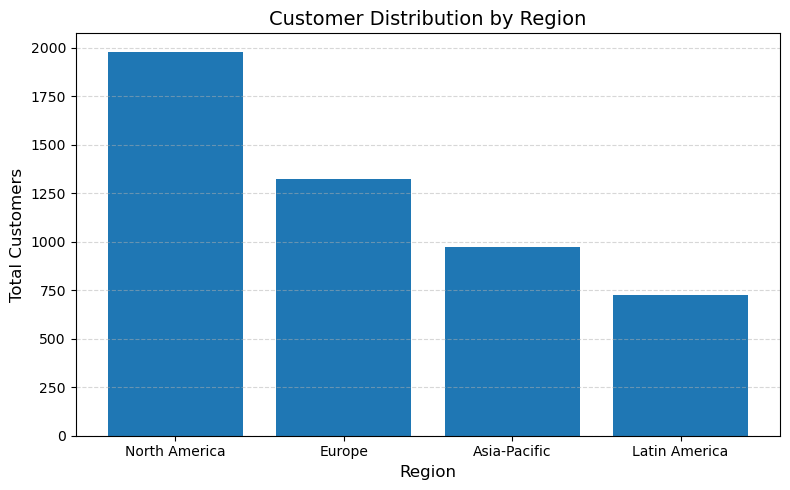

In [22]:
plt.figure(figsize=(8,5))

plt.bar(
    region_distribution["region"],
    region_distribution["total_customers"]
)

plt.title("Customer Distribution by Region", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Customers", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

### Business Insight:
North America has the largest customer base with 1,976 customers, accounting for the highest concentration of GrowthFlow customers among the four regions. Europe follows with 1,322 customers, while Asia-Pacific and Latin America have 974 and 728 customers, respectively.

The results indicate that GrowthFlow's customer base is not evenly distributed across regions. North America represents the company's strongest market presence, whereas Latin America has the smallest customer base. These differences provide a useful baseline for subsequent analyses to determine whether customer distribution is associated with variations in revenue, product usage, customer engagement, customer satisfaction, or retention across regions.

---
## Business Question 2

**Question:**
How are customers distributed across different subscription plans?

**Objective:**
To examine the distribution of customers across GrowthFlow's subscription plans and identify the most widely adopted plans. Understanding plan adoption provides insight into customer preferences and establishes a foundation for analyzing differences in revenue, feature usage, customer engagement, and retention across subscription tiers.

In [23]:
query = """
SELECT
    plan_type,
    COUNT(customer_id) AS total_customers
FROM customer_information
GROUP BY plan_type
ORDER BY total_customers DESC;
"""

plan_distribution = pd.read_sql(query, conn)

plan_distribution

,plan_type,total_customers
0,Basic,2658
1,Pro,1480
2,Enterprise,862


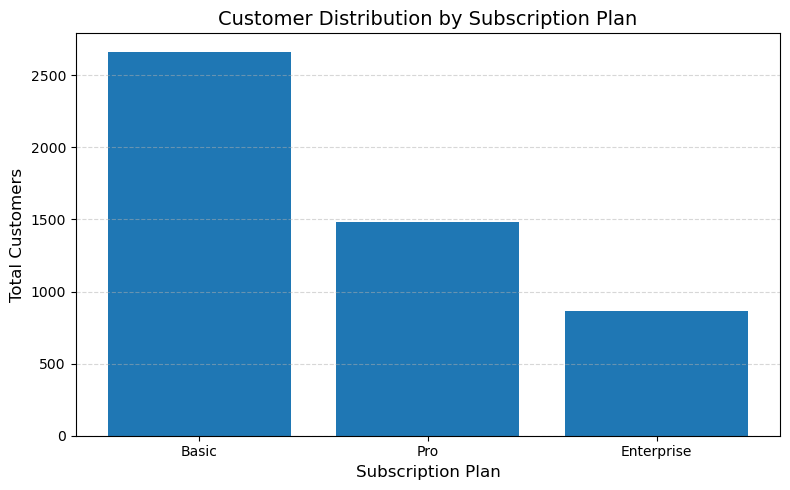

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    plan_distribution["plan_type"],
    plan_distribution["total_customers"]
)

plt.title("Customer Distribution by Subscription Plan", fontsize=14)
plt.xlabel("Subscription Plan", fontsize=12)
plt.ylabel("Total Customers", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

### Business Insight:
The Basic subscription plan has the highest customer adoption with 2,658 customers, followed by the Pro plan with 1,480 customers, while the Enterprise plan has the smallest customer base at 862 customers. This distribution indicates that the majority of GrowthFlow's customers are subscribed to the Basic plan, suggesting that it serves as the company's primary entry-level offering. The smaller customer base in the Enterprise tier may reflect its specialized nature or higher pricing. Further analysis is required to determine how subscription plans differ in terms of revenue generation, product usage, customer engagement, satisfaction, and retention.

---
## Business Question 3
**Question:**
How are customers distributed across different customer types?

**Objective:**
To examine the distribution of customers across different customer types and identify the composition of GrowthFlow's customer base. This analysis provides a foundation for understanding how customer segments may differ in revenue, product usage, engagement, and satisfaction.

In [25]:
query = """
SELECT
    customer_type,
    COUNT(customer_id) AS total_customers
FROM customer_information
GROUP BY customer_type
ORDER BY total_customers DESC;
"""

customer_type_distribution = pd.read_sql(query, conn)

customer_type_distribution

,customer_type,total_customers
0,SMB,3012
1,Mid-market,1255
2,Enterprise,733


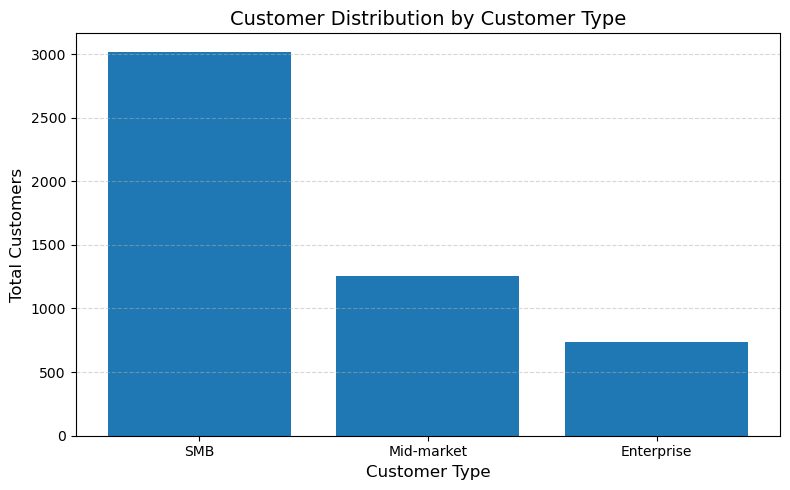

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    customer_type_distribution["customer_type"],
    customer_type_distribution["total_customers"]
)

plt.title("Customer Distribution by Customer Type", fontsize=14)
plt.xlabel("Customer Type", fontsize=12)
plt.ylabel("Total Customers", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

### Business Insight:
SMB customers represent the largest customer segment, with 3,012 customers, accounting for the majority of GrowthFlow's customer base. This is followed by the Mid-market segment with 1,255 customers, while the Enterprise segment has the fewest customers at 733. This distribution suggests that GrowthFlow's products are most widely adopted by small and medium-sized businesses. The differences in customer composition provide a basis for further analysis to determine whether customer segments differ in revenue generation, product usage, customer engagement, satisfaction, and retention.

---
## Business Question 4
**Question:**
How are customers distributed across different industries?

**Objective:**
To examine the distribution of customers across industries and identify the sectors with the highest and lowest customer representation. Understanding industry distribution provides context for evaluating whether customer behavior, revenue, engagement, and retention vary across different industries.

In [27]:
query = """
SELECT
    industry,
    COUNT(customer_id) AS total_customers
FROM customer_information
GROUP BY industry
ORDER BY total_customers DESC;
"""

industry_distribution = pd.read_sql(query, conn)

industry_distribution

,industry,total_customers
0,Retail,863
1,Technology,846
2,Finance,837
3,E-commerce,830
4,Healthcare,816
5,Education,808


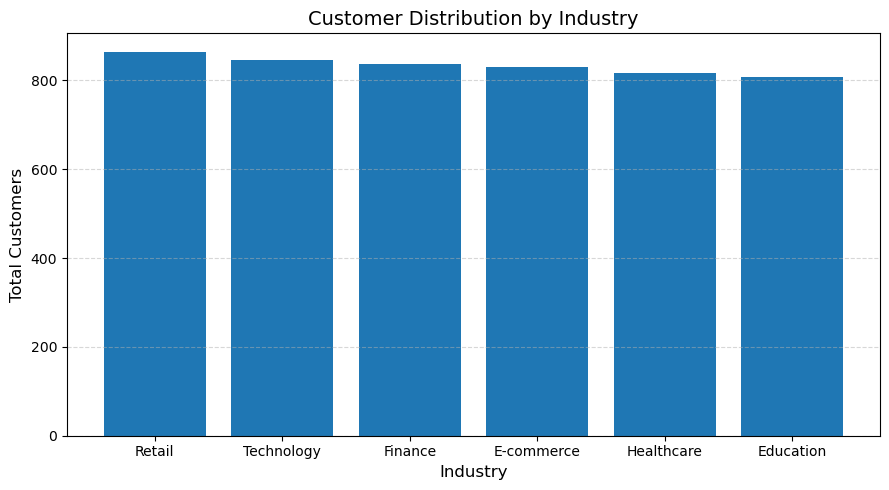

In [28]:
plt.figure(figsize=(9,5))

plt.bar(
    industry_distribution["industry"],
    industry_distribution["total_customers"]
)

plt.title("Customer Distribution by Industry", fontsize=14)
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Total Customers", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

### Business Insight:
Retail has the highest customer representation with 863 customers, closely followed by Technology (846), Finance (837), E-commerce (830), Healthcare (816), and Education (808). The relatively small differences in customer counts indicate that GrowthFlow maintains a well-balanced customer base across multiple industries rather than relying heavily on a single sector. This balanced distribution provides a suitable foundation for comparing customer behavior, revenue, engagement, satisfaction, and retention across industries without substantial imbalance in customer representation.

---
## 4.4 Section 2: Customer Behavior and Business Performance
## Business Question 5
**Question:**
How does monthly revenue vary across different subscription plans?

**Objective:**
To compare monthly revenue across subscription plans and identify which plans contribute the most to GrowthFlow's revenue. This analysis helps evaluate the financial performance of each subscription tier and provides insight into the relationship between plan adoption and revenue generation.

In [29]:
query = """
SELECT
    plan_type,
    ROUND(AVG(monthly_revenue), 2) AS average_monthly_revenue,
    ROUND(SUM(monthly_revenue), 2) AS total_monthly_revenue
FROM monthly_status
GROUP BY plan_type
ORDER BY total_monthly_revenue DESC;
"""

plan_revenue = pd.read_sql(query, conn)

plan_revenue

,plan_type,average_monthly_revenue,total_monthly_revenue
0,Enterprise,757.8,7465049.0
1,Pro,162.0,2643085.0
2,Basic,35.4,985945.0


##### Chart 1: Average Monthly Revenue

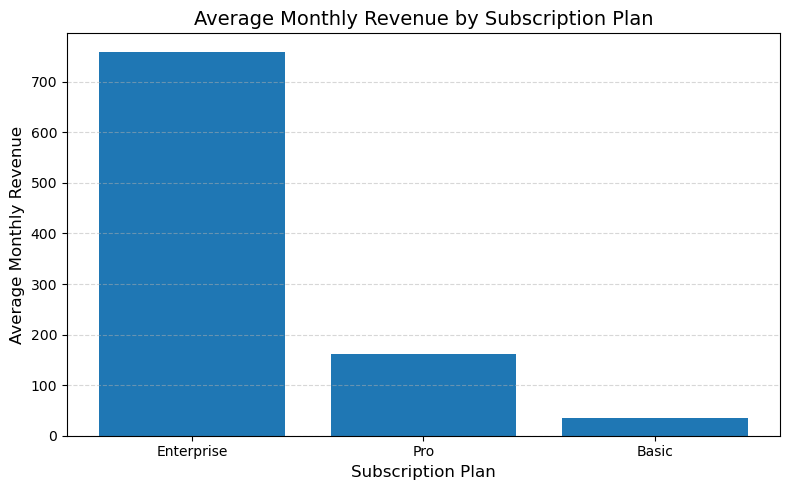

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    plan_revenue["plan_type"],
    plan_revenue["average_monthly_revenue"]
)

plt.title("Average Monthly Revenue by Subscription Plan", fontsize=14)
plt.xlabel("Subscription Plan", fontsize=12)
plt.ylabel("Average Monthly Revenue", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

##### Chart 2: Total Monthly Revenue

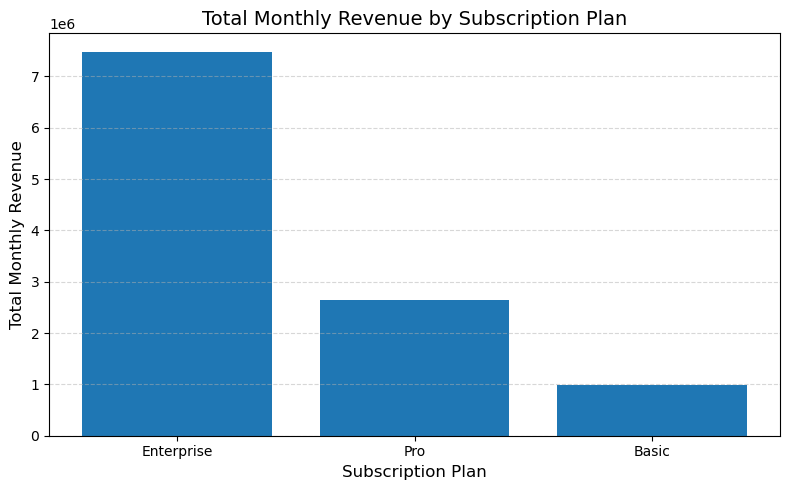

In [31]:
plt.figure(figsize=(8,5))

plt.bar(
    plan_revenue["plan_type"],
    plan_revenue["total_monthly_revenue"]
)

plt.title("Total Monthly Revenue by Subscription Plan", fontsize=14)
plt.xlabel("Subscription Plan", fontsize=12)
plt.ylabel("Total Monthly Revenue", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

### Business Insight:
The Enterprise subscription plan generates the highest average monthly revenue (757.80) and the highest total monthly revenue (7,465,049), making it GrowthFlow's most valuable subscription tier from a revenue perspective. The Pro plan ranks second, with an average monthly revenue of 162.00 and a total monthly revenue of 2,643,085, while the Basic plan contributes the lowest average (35.40) and total monthly revenue (985,945). Although the Basic plan has the largest customer base (as observed in the customer demographics analysis), the Enterprise plan contributes substantially more revenue per customer and overall. This highlights the significant financial value of higher-tier subscriptions to GrowthFlow's business performance.

---
## Business Question 6
**Question:**
How does feature usage vary across different subscription plans?

**Objective:**
To compare feature adoption across subscription plans and identify which features are most frequently used by customers in each subscription tier. This analysis helps determine whether higher-value subscription plans are associated with greater utilization of GrowthFlow's core features.

In [32]:
query = """
SELECT
    ms.plan_type,
    ROUND(AVG(ud.feature_crm), 2) AS avg_crm_usage,
    ROUND(AVG(ud.feature_email_campaigns), 2) AS avg_email_usage,
    ROUND(AVG(ud.feature_analytics), 2) AS avg_analytics_usage,
    ROUND(AVG(ud.feature_automation), 2) AS avg_automation_usage,
    ROUND(AVG(ud.feature_advanced_analytics), 2) AS avg_advanced_analytics_usage,
    ROUND(AVG(ud.feature_custom_workflows), 2) AS avg_custom_workflows_usage
FROM usage_data AS ud
INNER JOIN monthly_status AS ms
    ON ud.customer_id = ms.customer_id
    AND ud.months_since_sub = ms.months_since_sub
GROUP BY ms.plan_type
ORDER BY ms.plan_type;
"""

feature_usage = pd.read_sql(query, conn)

feature_usage

,plan_type,avg_crm_usage,avg_email_usage,avg_analytics_usage,avg_automation_usage,avg_advanced_analytics_usage,avg_custom_workflows_usage
0,Basic,0.81,0.57,0.46,0.28,0.00,0.00
1,Enterprise,1.86,1.34,1.07,0.64,0.43,0.26
2,Pro,1.08,0.77,0.63,0.38,0.25,0.00


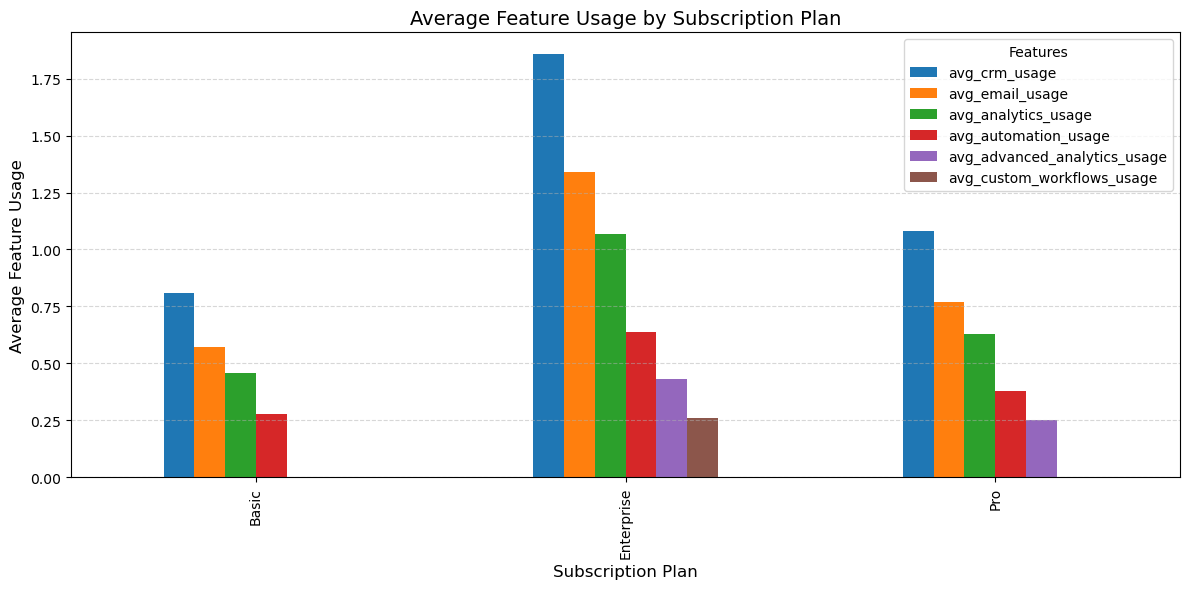

In [33]:
feature_usage.set_index("plan_type").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average Feature Usage by Subscription Plan", fontsize=14)
plt.xlabel("Subscription Plan", fontsize=12)
plt.ylabel("Average Feature Usage", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(title="Features")

plt.tight_layout()

plt.show()

### Business Insight:
Feature usage increases consistently across subscription tiers, with Enterprise customers exhibiting the highest average usage for every feature, followed by Pro, while Basic customers demonstrate the lowest feature utilization. CRM remains the most frequently used feature across all subscription plans, whereas Advanced Analytics and Custom Workflows are primarily used by Enterprise customers. Notably, Basic customers show no usage of Advanced Analytics or Custom Workflows, while Pro customers also show no usage of Custom Workflows. These findings align with the previous revenue analysis, where the Enterprise plan generated the highest average and total monthly revenue, suggesting that customers on higher-tier subscription plans derive greater value from GrowthFlow's advanced capabilities.

---
## Business Question 7
**Question:**
How does customer engagement vary across different subscription plans?

**Objective:**
To compare customer engagement across subscription plans and determine whether higher subscription tiers are associated with greater customer interaction. This analysis helps assess the relationship between subscription level and customer engagement.

In [34]:
query = """
SELECT
    ms.plan_type,
    ROUND(AVG(ed.engagement_count), 2) AS avg_engagement_count,
    ROUND(AVG(ed.response_rate), 2) AS avg_response_rate,
    ROUND(AVG(ed.avg_response_rate), 2) AS overall_avg_response_rate
FROM engagement_data ed
JOIN monthly_status ms
    ON ed.customer_id = ms.customer_id
    AND ed.engagement_month = ms.activity_month
GROUP BY ms.plan_type
ORDER BY ms.plan_type;
"""

engagement_analysis = pd.read_sql(query, conn)

engagement_analysis

,plan_type,avg_engagement_count,avg_response_rate,overall_avg_response_rate
0,Basic,1.13,0.46,0.45
1,Enterprise,1.24,0.69,0.70
2,Pro,1.17,0.54,0.54


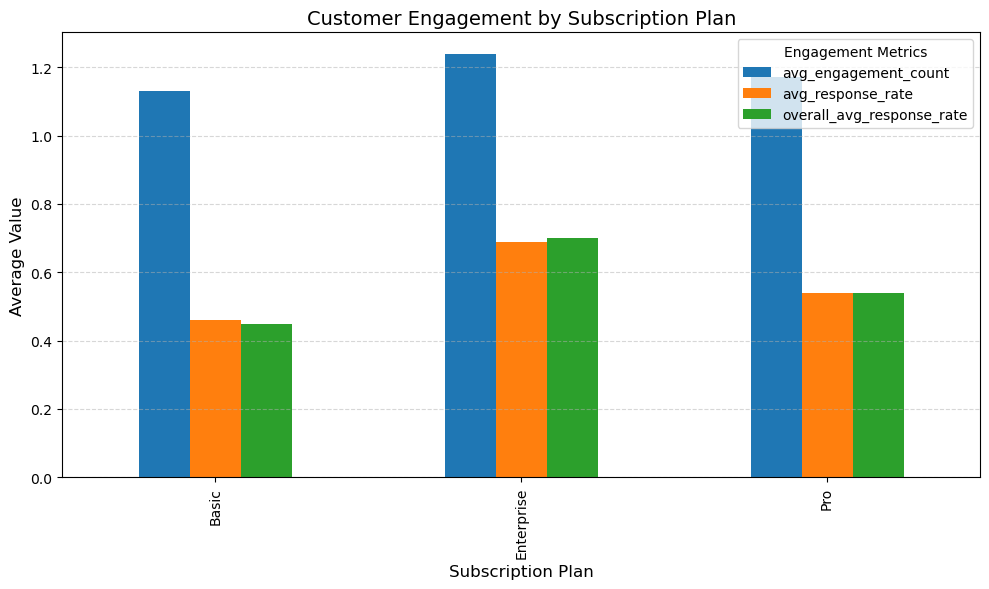

In [35]:
engagement_analysis.set_index("plan_type").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Customer Engagement by Subscription Plan", fontsize=14)
plt.xlabel("Subscription Plan", fontsize=12)
plt.ylabel("Average Value", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(title="Engagement Metrics")

plt.tight_layout()

plt.show()

### Business Insight:
Enterprise customers demonstrate the highest level of engagement across all measured metrics, recording the highest average engagement count (1.24), average response rate (0.69), and overall average response rate (0.70). Pro customers consistently rank second, while Basic customers exhibit the lowest engagement levels. These findings reinforce the results of the previous analyses, where Enterprise customers generated the highest revenue and showed the greatest feature utilization. Together, the results suggest a positive relationship between subscription tier, product usage, customer engagement, and revenue generation.

---
## Business Question 8
**Question:**
How does customer satisfaction vary across different subscription plans?

**Objective:**
To compare customer satisfaction across subscription plans and determine whether higher subscription tiers are associated with greater customer satisfaction. This analysis provides insight into how customer experience differs across GrowthFlow's subscription offerings.

In [36]:
query = """
SELECT
    ms.plan_type,
    ROUND(AVG(fd.satisfaction_score), 2) AS avg_satisfaction_score,
    ROUND(AVG(fd.nps_score), 2) AS avg_nps_score
FROM feedback_data fd
JOIN monthly_status ms
    ON fd.customer_id = ms.customer_id
    AND fd.feedback_month = ms.activity_month
GROUP BY ms.plan_type
ORDER BY ms.plan_type;
"""

customer_satisfaction = pd.read_sql(query, conn)

customer_satisfaction

,plan_type,avg_satisfaction_score,avg_nps_score
0,Basic,7.00,19.95
1,Enterprise,7.89,28.20
2,Pro,7.23,21.73


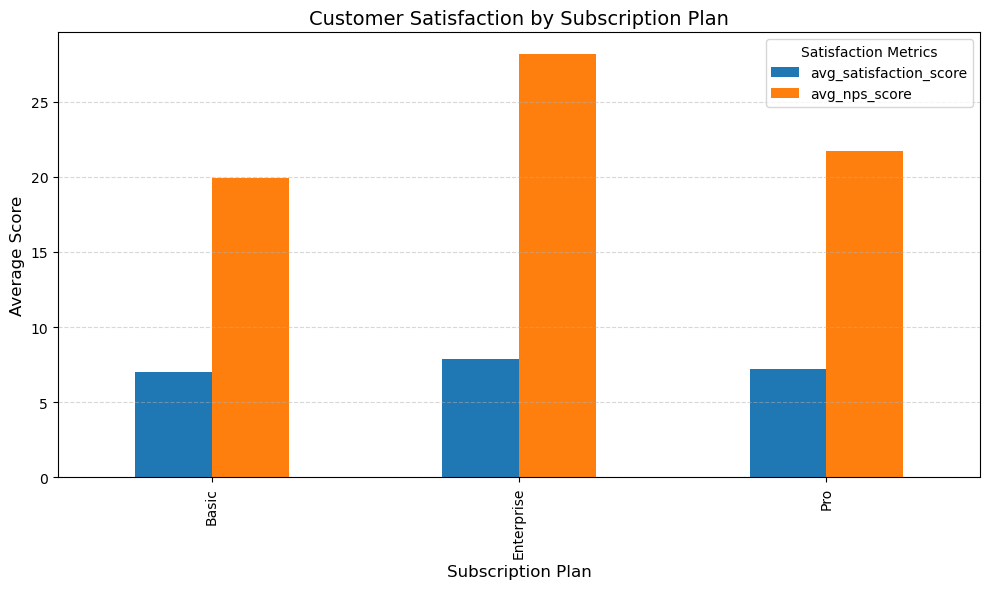

In [37]:
customer_satisfaction.set_index("plan_type").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Customer Satisfaction by Subscription Plan", fontsize=14)
plt.xlabel("Subscription Plan", fontsize=12)
plt.ylabel("Average Score", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(title="Satisfaction Metrics")

plt.tight_layout()

plt.show()

### Business Insight:
Enterprise customers report the highest levels of customer satisfaction, with an average satisfaction score of 7.89 and an average Net Promoter Score (NPS) of 28.20. Pro customers rank second, while Basic customers record the lowest satisfaction and NPS values. These findings are consistent with the previous analyses, where Enterprise customers demonstrated the highest revenue contribution, feature utilization, and customer engagement. Collectively, the results suggest that customers on higher-tier subscription plans experience greater value from GrowthFlow's services, leading to stronger engagement and higher satisfaction.

---
## Business Question 9

**Question:**
What are the most common feedback categories reported by customers?

**Objective:**
To identify the most frequently reported customer feedback categories and understand the primary areas where customers provide feedback. This analysis helps highlight aspects of the product or service that receive the greatest customer attention and may guide future product improvements.

In [38]:
query = """
SELECT
    feedback_category,
    COUNT(*) AS total_feedback
FROM feedback_data
GROUP BY feedback_category
ORDER BY total_feedback DESC;
"""

feedback_category_analysis = pd.read_sql(query, conn)

feedback_category_analysis

,feedback_category,total_feedback
0,Product,641
1,Features,465
2,Support,215
3,Integration,116
4,Pricing,10


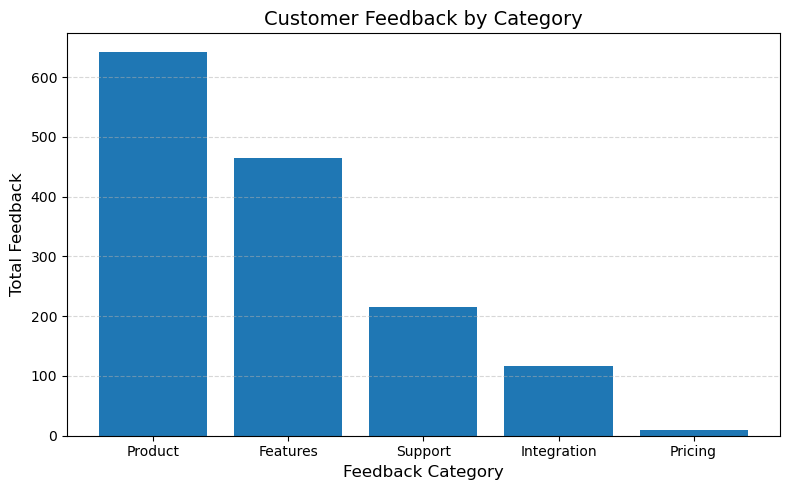

In [39]:
plt.figure(figsize=(8,5))

plt.bar(
    feedback_category_analysis["feedback_category"],
    feedback_category_analysis["total_feedback"]
)

plt.title("Customer Feedback by Category", fontsize=14)
plt.xlabel("Feedback Category", fontsize=12)
plt.ylabel("Total Feedback", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

### Business Insight:
Product-related feedback is the most frequently reported category, accounting for 641 feedback records, followed by Features (465) and Support (215). Comparatively fewer customers provided feedback related to Integration (116), while Pricing (10) received the least attention. These findings suggest that customers primarily focus their feedback on the product's functionality and feature set rather than pricing. This information can help GrowthFlow prioritize product enhancements and feature improvements while continuing to monitor support and integration-related concerns.

---
## 4.5 Summary of Key Findings
### Summary

The exploratory data analysis provided valuable insights into GrowthFlow's customer base, customer behavior, and business performance. The analysis revealed that North America represents the largest customer region, while the Basic subscription plan accounts for the largest share of customers. However, despite having fewer customers, the Enterprise subscription plan consistently outperformed other plans across multiple business metrics.

Enterprise customers generated the highest average and total monthly revenue, demonstrated the greatest feature utilization, recorded the highest engagement levels, and reported the strongest customer satisfaction and Net Promoter Scores (NPS). These consistent findings suggest that higher-tier subscription plans are associated with increased customer value, stronger product adoption, and greater customer loyalty.

The analysis also showed that customer feedback is primarily concentrated around product functionality and feature improvements, indicating that these areas are the primary focus of customer attention and represent important opportunities for continuous product enhancement.

Overall, the exploratory data analysis established a comprehensive understanding of GrowthFlow's customer demographics, customer behavior, and business performance, providing a strong analytical foundation for the predictive modeling and feature engineering tasks that follow in subsequent phases of the project.

---
# Day 5 - Data Integration and Analytical Dataset Creation

## 5.1 Objective

The objective of Day 5 is to integrate the customer information, monthly subscription status, product usage, engagement, and feedback datasets into one analytical dataset.

The datasets will be merged using appropriate customer and monthly identifiers while preserving the monthly customer records contained in the monthly status dataset.

After each merge, the dataset dimensions and matching results will be validated to prevent unintended row duplication or data loss.

---
## 5.2 Create the first integrated dataset
We will use monthly_status as the base table because it contains the customer-month records we want to preserve.

In [40]:
master_data = pd.read_sql(query, conn)

In [41]:
query = """
SELECT
    ms.*,
    ci.subscription_date,
    ci.company_size
FROM monthly_status AS ms
LEFT JOIN customer_information AS ci
    ON ms.customer_id = ci.customer_id;
"""

master_data = pd.read_sql(query, conn)

master_data.head()

,customer_id,cohort,activity_month,months_since_sub,is_active,monthly_revenue,customer_type,plan_type,region,industry,subscription_date,company_size
0,CUST_00001,2024-04-01,2024-04-01 00:00:00,0,1,49,Mid-market,Basic,Europe,Finance,2024-04-12 00:00:00,171
1,CUST_00001,2024-04-01,2024-05-01 00:00:00,1,1,49,Mid-market,Basic,Europe,Finance,2024-04-12 00:00:00,171
2,CUST_00001,2024-04-01,2024-06-01 00:00:00,2,1,49,Mid-market,Basic,Europe,Finance,2024-04-12 00:00:00,171
3,CUST_00001,2024-04-01,2024-07-01 00:00:00,3,1,49,Mid-market,Basic,Europe,Finance,2024-04-12 00:00:00,171
4,CUST_00001,2024-04-01,2024-08-01 00:00:00,4,1,49,Mid-market,Basic,Europe,Finance,2024-04-12 00:00:00,171


In [42]:
# Verify the shape

print("Monthly status shape:", monthly_status.shape)
print("Master data shape:", master_data.shape)

Monthly status shape: (54021, 10)
Master data shape: (54021, 12)


In [43]:
# Check whether the two new columns merged successfully

master_data[
    ["subscription_date", "company_size"]
].isnull().sum()

subscription_date    0
company_size         0
dtype: int64

In [44]:
# Save the Updated Master Dataset

master_data.to_sql(
    "master_data",
    conn,
    if_exists="replace",
    index=False
)

54021

---
## 5.3 Merge Usage Data

This is the first table that has monthly activity, so we'll join on:

- customer_id
- months_since_sub

These two columns uniquely identify each customer's monthly record.

In [45]:
query = """
SELECT
    md.customer_id,
    md.cohort,
    md.activity_month,
    md.months_since_sub,
    md.is_active,
    md.monthly_revenue,
    md.customer_type,
    md.plan_type,
    md.region,
    md.industry,
    md.subscription_date,
    md.company_size,

    ud.session_duration,
    ud.feature_crm,
    ud.feature_email_campaigns,
    ud.feature_analytics,
    ud.feature_automation,
    ud.feature_advanced_analytics,
    ud.feature_custom_workflows

FROM master_data AS md

LEFT JOIN usage_data AS ud
ON md.customer_id = ud.customer_id
AND md.months_since_sub = ud.months_since_sub;
"""

master_data = pd.read_sql(query, conn)

master_data.head()

,customer_id,cohort,activity_month,months_since_sub,is_active,monthly_revenue,customer_type,plan_type,region,industry,subscription_date,company_size,session_duration,feature_crm,feature_email_campaigns,feature_analytics,feature_automation,feature_advanced_analytics,feature_custom_workflows
0,CUST_00001,2024-04-01,2024-04-01 00:00:00,0,1,49,Mid-market,Basic,Europe,Finance,2024-04-12 00:00:00,171,23,1,0,1,1,0,0
1,CUST_00001,2024-04-01,2024-05-01 00:00:00,1,1,49,Mid-market,Basic,Europe,Finance,2024-04-12 00:00:00,171,31,1,3,1,0,0,0
2,CUST_00001,2024-04-01,2024-06-01 00:00:00,2,1,49,Mid-market,Basic,Europe,Finance,2024-04-12 00:00:00,171,31,2,2,1,1,0,0
3,CUST_00001,2024-04-01,2024-07-01 00:00:00,3,1,49,Mid-market,Basic,Europe,Finance,2024-04-12 00:00:00,171,41,1,1,1,1,0,0
4,CUST_00001,2024-04-01,2024-08-01 00:00:00,4,1,49,Mid-market,Basic,Europe,Finance,2024-04-12 00:00:00,171,63,1,0,1,0,0,0


In [46]:
# Verify the merge

print("Master data shape:", master_data.shape)

Master data shape: (54021, 19)


In [47]:
# Verify the merge quality

master_data[
    [
        "session_duration",
        "feature_crm",
        "feature_email_campaigns",
        "feature_analytics",
        "feature_automation",
        "feature_advanced_analytics",
        "feature_custom_workflows"
    ]
].isnull().sum()

session_duration              0
feature_crm                   0
feature_email_campaigns       0
feature_analytics             0
feature_automation            0
feature_advanced_analytics    0
feature_custom_workflows      0
dtype: int64

In [48]:
# Save the Updated Master Dataset

master_data.to_sql(
    "master_data",
    conn,
    if_exists="replace",
    index=False
)

54021

---
## 5.4 Merge Engagement Data
### Objective

Integrate customer engagement metrics into the analytical dataset to enrich customer behavior analysis.

In [49]:
query = """
SELECT
    md.customer_id,
    md.cohort,
    md.activity_month,
    md.months_since_sub,
    md.is_active,
    md.monthly_revenue,
    md.customer_type,
    md.plan_type,
    md.region,
    md.industry,
    md.subscription_date,
    md.company_size,
    md.session_duration,
    md.feature_crm,
    md.feature_email_campaigns,
    md.feature_analytics,
    md.feature_automation,
    md.feature_advanced_analytics,
    md.feature_custom_workflows,

    ed.engagement_count,
    ed.response_rate,
    ed.avg_response_rate

FROM master_data AS md

LEFT JOIN engagement_data AS ed
ON md.customer_id = ed.customer_id
AND md.activity_month = ed.engagement_month;
"""

master_data = pd.read_sql(query, conn)

master_data.head()

,customer_id,cohort,activity_month,months_since_sub,is_active,monthly_revenue,customer_type,plan_type,region,industry,...,session_duration,feature_crm,feature_email_campaigns,feature_analytics,feature_automation,feature_advanced_analytics,feature_custom_workflows,engagement_count,response_rate,avg_response_rate
0,CUST_00001,2024-04-01,2024-04-01 00:00:00,0,1,49,Mid-market,Basic,Europe,Finance,...,23,1,0,1,1,0,0,NaN,NaN,NaN
1,CUST_00001,2024-04-01,2024-05-01 00:00:00,1,1,49,Mid-market,Basic,Europe,Finance,...,31,1,3,1,0,0,0,NaN,NaN,NaN
2,CUST_00001,2024-04-01,2024-06-01 00:00:00,2,1,49,Mid-market,Basic,Europe,Finance,...,31,2,2,1,1,0,0,NaN,NaN,NaN
3,CUST_00001,2024-04-01,2024-07-01 00:00:00,3,1,49,Mid-market,Basic,Europe,Finance,...,41,1,1,1,1,0,0,NaN,NaN,NaN
4,CUST_00001,2024-04-01,2024-08-01 00:00:00,4,1,49,Mid-market,Basic,Europe,Finance,...,63,1,0,1,0,0,0,NaN,NaN,NaN


In [50]:
# Verify the merge

print("Master data shape:", master_data.shape)

Master data shape: (54021, 22)


In [51]:
# Verify new columns

master_data[
    [
        "engagement_count",
        "response_rate",
        "avg_response_rate"
    ]
].isnull().sum()

engagement_count     41261
response_rate        41261
avg_response_rate    41261
dtype: int64

In [52]:
# Verify monthly_staus and engagement_status shapes

print(monthly_status.shape)
print(engagement_data.shape)

(54021, 10)
(14532, 5)


In [53]:
# Checking unmatched records

unmatched_engagement = pd.read_sql(
    """
    SELECT ed.*
    FROM engagement_data AS ed
    LEFT JOIN master_data AS md
        ON ed.customer_id = md.customer_id
        AND DATE(ed.engagement_month) = DATE(md.activity_month)
    WHERE md.customer_id IS NULL;
    """,
    conn
)

print(unmatched_engagement.shape)
unmatched_engagement.head()

(2001, 5)


,customer_id,engagement_month,engagement_count,response_rate,avg_response_rate
0,CUST_00005,2025-11-01 00:00:00,1,1.0,0.39
1,CUST_00006,2025-02-01 00:00:00,1,1.0,0.35
2,CUST_00006,2025-04-01 00:00:00,1,0.0,0.35
3,CUST_00006,2025-10-01 00:00:00,1,1.0,0.39
4,CUST_00007,2025-12-01 00:00:00,1,0.0,0.55


In [54]:
# Checking merged shape

print(master_data.shape)

(54021, 22)


In [55]:
# Identifying repeated engagement keys

duplicate_engagement_months = pd.read_sql(
    """
    SELECT
        customer_id,
        DATE(engagement_month) AS engagement_month,
        COUNT(*) AS record_count
    FROM engagement_data
    GROUP BY
        customer_id,
        DATE(engagement_month)
    HAVING COUNT(*) > 1
    ORDER BY record_count DESC;
    """,
    conn
)

print(duplicate_engagement_months.shape)
duplicate_engagement_months.head()

(0, 3)


,customer_id,engagement_month,record_count


In [56]:
# Save the Updated Master Dataset

master_data.to_sql(
    "master_data",
    conn,
    if_exists="replace",
    index=False
)

54021

### Observation: 
The engagement merge preserved all 54,021 customer-month records without creating duplicates. Engagement information was available for only a subset of these records, resulting in missing engagement values for months without recorded interactions. Additionally, some engagement records did not correspond to months represented in the monthly-status dataset and were therefore excluded by the customer-month integration structure.

---
## 5.5 Merge Feedback Data

Feedback is recorded only for some customer-months, so we will use a LEFT JOIN to preserve all 54,021 rows in master_data.

### Objective

Integrate customer satisfaction, Net Promoter Score, and feedback-category information into the analytical dataset.

In [57]:
query = """
SELECT
    md.customer_id,
    md.cohort,
    md.activity_month,
    md.months_since_sub,
    md.is_active,
    md.monthly_revenue,
    md.customer_type,
    md.plan_type,
    md.region,
    md.industry,
    md.subscription_date,
    md.company_size,
    md.session_duration,
    md.feature_crm,
    md.feature_email_campaigns,
    md.feature_analytics,
    md.feature_automation,
    md.feature_advanced_analytics,
    md.feature_custom_workflows,
    md.engagement_count,
    md.response_rate,
    md.avg_response_rate,

    fd.satisfaction_score,
    fd.nps_score,
    fd.feedback_category

FROM master_data AS md

LEFT JOIN feedback_data AS fd
    ON md.customer_id = fd.customer_id
    AND DATE(md.activity_month) = DATE(fd.feedback_month);
"""

master_data = pd.read_sql(query, conn)

master_data.head()

,customer_id,cohort,activity_month,months_since_sub,is_active,monthly_revenue,customer_type,plan_type,region,industry,...,feature_analytics,feature_automation,feature_advanced_analytics,feature_custom_workflows,engagement_count,response_rate,avg_response_rate,satisfaction_score,nps_score,feedback_category
0,CUST_00001,2024-04-01,2024-04-01 00:00:00,0,1,49,Mid-market,Basic,Europe,Finance,...,1,1,0,0,NaN,NaN,NaN,NaN,NaN,None
1,CUST_00001,2024-04-01,2024-05-01 00:00:00,1,1,49,Mid-market,Basic,Europe,Finance,...,1,0,0,0,NaN,NaN,NaN,NaN,NaN,None
2,CUST_00001,2024-04-01,2024-06-01 00:00:00,2,1,49,Mid-market,Basic,Europe,Finance,...,1,1,0,0,NaN,NaN,NaN,NaN,NaN,None
3,CUST_00001,2024-04-01,2024-07-01 00:00:00,3,1,49,Mid-market,Basic,Europe,Finance,...,1,1,0,0,NaN,NaN,NaN,NaN,NaN,None
4,CUST_00001,2024-04-01,2024-08-01 00:00:00,4,1,49,Mid-market,Basic,Europe,Finance,...,1,0,0,0,NaN,NaN,NaN,NaN,NaN,None


In [58]:
# Verify the shape

print("Master data shape:", master_data.shape)

Master data shape: (54036, 25)


In [59]:
# Check the new columns

master_data[
    [
        "satisfaction_score",
        "nps_score",
        "feedback_category"
    ]
].isnull().sum()

satisfaction_score    52812
nps_score             52812
feedback_category     52812
dtype: int64

In [60]:
# Confirming that the rows were not duplicated

print("Expected rows:", monthly_status.shape[0])
print("Actual rows:", master_data.shape[0])

Expected rows: 54021
Actual rows: 54036


In [61]:
# Saving the final merged version into SQLite

master_data.to_sql(
    "master_data",
    conn,
    if_exists="replace",
    index=False
)

54036

---
## 5.6 Export the Final Analytical Dataset

### Objective

Export the integrated dataset for future exploratory analysis, dashboarding, and machine learning.

In [62]:
master_data.to_csv(
    "growthflow_master_dataset.csv",
    index=False
)

print("Final analytical dataset exported successfully")

Final analytical dataset exported successfully


In [63]:
# Verify exported dataset

master_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54036 entries, 0 to 54035
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 54036 non-null  object 
 1   cohort                      54036 non-null  object 
 2   activity_month              54036 non-null  object 
 3   months_since_sub            54036 non-null  int64  
 4   is_active                   54036 non-null  int64  
 5   monthly_revenue             54036 non-null  int64  
 6   customer_type               54036 non-null  object 
 7   plan_type                   54036 non-null  object 
 8   region                      54036 non-null  object 
 9   industry                    54036 non-null  object 
 10  subscription_date           54036 non-null  object 
 11  company_size                54036 non-null  int64  
 12  session_duration            54036 non-null  int64  
 13  feature_crm                 540

In [64]:
master_data.head()

,customer_id,cohort,activity_month,months_since_sub,is_active,monthly_revenue,customer_type,plan_type,region,industry,...,feature_analytics,feature_automation,feature_advanced_analytics,feature_custom_workflows,engagement_count,response_rate,avg_response_rate,satisfaction_score,nps_score,feedback_category
0,CUST_00001,2024-04-01,2024-04-01 00:00:00,0,1,49,Mid-market,Basic,Europe,Finance,...,1,1,0,0,NaN,NaN,NaN,NaN,NaN,None
1,CUST_00001,2024-04-01,2024-05-01 00:00:00,1,1,49,Mid-market,Basic,Europe,Finance,...,1,0,0,0,NaN,NaN,NaN,NaN,NaN,None
2,CUST_00001,2024-04-01,2024-06-01 00:00:00,2,1,49,Mid-market,Basic,Europe,Finance,...,1,1,0,0,NaN,NaN,NaN,NaN,NaN,None
3,CUST_00001,2024-04-01,2024-07-01 00:00:00,3,1,49,Mid-market,Basic,Europe,Finance,...,1,1,0,0,NaN,NaN,NaN,NaN,NaN,None
4,CUST_00001,2024-04-01,2024-08-01 00:00:00,4,1,49,Mid-market,Basic,Europe,Finance,...,1,0,0,0,NaN,NaN,NaN,NaN,NaN,None


# Week 4

---
## 6.1 Verify Cohort Information
### Objective

Confirm that the cohort and months since subscription fields already exist and are correctly populated before beginning retention analysis.

In [65]:
# Check relevant columns

master_data[
    [
        "customer_id",
        "subscription_date",
        "cohort",
        "activity_month",
        "months_since_sub"
    ]
].head(10)

,customer_id,subscription_date,cohort,activity_month,months_since_sub
0,CUST_00001,2024-04-12 00:00:00,2024-04-01,2024-04-01 00:00:00,0
1,CUST_00001,2024-04-12 00:00:00,2024-04-01,2024-05-01 00:00:00,1
2,CUST_00001,2024-04-12 00:00:00,2024-04-01,2024-06-01 00:00:00,2
3,CUST_00001,2024-04-12 00:00:00,2024-04-01,2024-07-01 00:00:00,3
4,CUST_00001,2024-04-12 00:00:00,2024-04-01,2024-08-01 00:00:00,4
5,CUST_00001,2024-04-12 00:00:00,2024-04-01,2024-09-01 00:00:00,5
6,CUST_00001,2024-04-12 00:00:00,2024-04-01,2024-10-01 00:00:00,6
7,CUST_00001,2024-04-12 00:00:00,2024-04-01,2024-11-01 00:00:00,7
8,CUST_00001,2024-04-12 00:00:00,2024-04-01,2024-12-01 00:00:00,8
9,CUST_00001,2024-04-12 00:00:00,2024-04-01,2025-01-01 00:00:00,9


In [66]:
# Verify missing values

master_data[
    [
        "cohort",
        "months_since_sub"
    ]
].isnull().sum()

cohort              0
months_since_sub    0
dtype: int64

In [67]:
# Verify cohort format

master_data["cohort"].unique()[:10]

array(['2024-04-01', '2025-04-01', '2024-05-01', '2024-07-01',
       '2025-07-01', '2024-01-01', '2025-01-01', '2024-09-01',
       '2024-10-01', '2025-06-01'], dtype=object)

---
## 6.2 Create the Cohort Activity Table
### Objective

Determine how many customers remain active in each subscription cohort over time. This creates the foundation for measuring customer retention.

### Step 1: Aggregate Active Customers (SQL)

In [75]:
query = """
SELECT
    cohort,
    months_since_sub,
    COUNT(DISTINCT customer_id) AS active_customers

FROM master_data

WHERE is_active = 1

GROUP BY
    cohort,
    months_since_sub

ORDER BY
    cohort,
    months_since_sub;
"""

cohort_activity = pd.read_sql(query, conn)

cohort_activity.head(15)

,cohort,months_since_sub,active_customers
0,2024-01-01,0,207
1,2024-01-01,1,207
2,2024-01-01,2,201
3,2024-01-01,3,201
4,2024-01-01,4,197
5,2024-01-01,5,188
6,2024-01-01,6,184
7,2024-01-01,7,179
8,2024-01-01,8,177
9,2024-01-01,9,175


---
### Step 2: Verify the Results

In [76]:
print(cohort_activity.shape)

cohort_activity.head(10)

(300, 3)


,cohort,months_since_sub,active_customers
0,2024-01-01,0,207
1,2024-01-01,1,207
2,2024-01-01,2,201
3,2024-01-01,3,201
4,2024-01-01,4,197
5,2024-01-01,5,188
6,2024-01-01,6,184
7,2024-01-01,7,179
8,2024-01-01,8,177
9,2024-01-01,9,175


### Step 3 – Check for Missing Values

In [77]:
cohort_activity.isnull().sum()

cohort              0
months_since_sub    0
active_customers    0
dtype: int64

## 6.3 Create the Cohort Matrix
### Objective

Reshape the cohort activity table so that each row represents a subscription cohort and each column represents the number of months since subscription.

In [78]:
cohort_matrix = cohort_activity.pivot(
    index="cohort",
    columns="months_since_sub",
    values="active_customers"
)

cohort_matrix

months_since_sub,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cohort,,,,,,,,,,,,,,,,,,,,,
2024-01-01,207.0,207.0,201.0,201.0,197.0,188.0,184.0,179.0,177.0,175.0,...,155.0,155.0,155.0,155.0,155.0,155.0,155.0,155.0,155.0,155.0
2024-02-01,190.0,190.0,184.0,183.0,179.0,174.0,172.0,165.0,159.0,154.0,...,135.0,135.0,135.0,135.0,135.0,135.0,135.0,135.0,135.0,NaN
2024-03-01,196.0,196.0,191.0,185.0,184.0,182.0,178.0,170.0,160.0,159.0,...,144.0,144.0,144.0,144.0,144.0,144.0,144.0,144.0,NaN,NaN
2024-04-01,203.0,203.0,197.0,190.0,184.0,178.0,173.0,169.0,163.0,159.0,...,135.0,135.0,135.0,135.0,135.0,135.0,135.0,NaN,NaN,NaN
2024-05-01,229.0,229.0,228.0,223.0,217.0,215.0,209.0,204.0,200.0,197.0,...,182.0,182.0,182.0,182.0,182.0,182.0,NaN,NaN,NaN,NaN
2024-06-01,207.0,207.0,203.0,199.0,192.0,190.0,188.0,181.0,177.0,172.0,...,154.0,154.0,154.0,154.0,154.0,NaN,NaN,NaN,NaN,NaN
2024-07-01,188.0,188.0,183.0,179.0,174.0,171.0,169.0,164.0,160.0,155.0,...,141.0,141.0,141.0,141.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-01,232.0,231.0,224.0,217.0,214.0,213.0,211.0,205.0,199.0,191.0,...,174.0,174.0,174.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-01,216.0,216.0,212.0,211.0,205.0,197.0,190.0,183.0,176.0,171.0,...,152.0,152.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
# Verify the result

print("Cohort matrix shape:", cohort_matrix.shape)

cohort_matrix.head()

Cohort matrix shape: (24, 24)


months_since_sub,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cohort,,,,,,,,,,,,,,,,,,,,,
2024-01-01,207.0,207.0,201.0,201.0,197.0,188.0,184.0,179.0,177.0,175.0,...,155.0,155.0,155.0,155.0,155.0,155.0,155.0,155.0,155.0,155.0
2024-02-01,190.0,190.0,184.0,183.0,179.0,174.0,172.0,165.0,159.0,154.0,...,135.0,135.0,135.0,135.0,135.0,135.0,135.0,135.0,135.0,NaN
2024-03-01,196.0,196.0,191.0,185.0,184.0,182.0,178.0,170.0,160.0,159.0,...,144.0,144.0,144.0,144.0,144.0,144.0,144.0,144.0,NaN,NaN
2024-04-01,203.0,203.0,197.0,190.0,184.0,178.0,173.0,169.0,163.0,159.0,...,135.0,135.0,135.0,135.0,135.0,135.0,135.0,NaN,NaN,NaN
2024-05-01,229.0,229.0,228.0,223.0,217.0,215.0,209.0,204.0,200.0,197.0,...,182.0,182.0,182.0,182.0,182.0,182.0,NaN,NaN,NaN,NaN


---
## 6.4 Calculate Cohort Retention Rates
### Objective

Convert the cohort activity counts into retention percentages by comparing the number of active customers in each month against the original cohort size (Month 0).

### Step 1 - Calculate Retention Rates

In [80]:
cohort_sizes = cohort_matrix[0]

retention_matrix = cohort_matrix.divide(
    cohort_sizes,
    axis=0
) * 100

retention_matrix.round(2)

months_since_sub,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cohort,,,,,,,,,,,,,,,,,,,,,
2024-01-01,100.0,100.00,97.10,97.10,95.17,90.82,88.89,86.47,85.51,84.54,...,74.88,74.88,74.88,74.88,74.88,74.88,74.88,74.88,74.88,74.88
2024-02-01,100.0,100.00,96.84,96.32,94.21,91.58,90.53,86.84,83.68,81.05,...,71.05,71.05,71.05,71.05,71.05,71.05,71.05,71.05,71.05,NaN
2024-03-01,100.0,100.00,97.45,94.39,93.88,92.86,90.82,86.73,81.63,81.12,...,73.47,73.47,73.47,73.47,73.47,73.47,73.47,73.47,NaN,NaN
2024-04-01,100.0,100.00,97.04,93.60,90.64,87.68,85.22,83.25,80.30,78.33,...,66.50,66.50,66.50,66.50,66.50,66.50,66.50,NaN,NaN,NaN
2024-05-01,100.0,100.00,99.56,97.38,94.76,93.89,91.27,89.08,87.34,86.03,...,79.48,79.48,79.48,79.48,79.48,79.48,NaN,NaN,NaN,NaN
2024-06-01,100.0,100.00,98.07,96.14,92.75,91.79,90.82,87.44,85.51,83.09,...,74.40,74.40,74.40,74.40,74.40,NaN,NaN,NaN,NaN,NaN
2024-07-01,100.0,100.00,97.34,95.21,92.55,90.96,89.89,87.23,85.11,82.45,...,75.00,75.00,75.00,75.00,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-01,100.0,99.57,96.55,93.53,92.24,91.81,90.95,88.36,85.78,82.33,...,75.00,75.00,75.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-01,100.0,100.00,98.15,97.69,94.91,91.20,87.96,84.72,81.48,79.17,...,70.37,70.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 2 - Verify the Results

In [81]:
print("Retention matrix shape:", retention_matrix.shape)

retention_matrix.head()

Retention matrix shape: (24, 24)


months_since_sub,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cohort,,,,,,,,,,,,,,,,,,,,,
2024-01-01,100.0,100.0,97.101449,97.101449,95.169082,90.821256,88.888889,86.473430,85.507246,84.541063,...,74.879227,74.879227,74.879227,74.879227,74.879227,74.879227,74.879227,74.879227,74.879227,74.879227
2024-02-01,100.0,100.0,96.842105,96.315789,94.210526,91.578947,90.526316,86.842105,83.684211,81.052632,...,71.052632,71.052632,71.052632,71.052632,71.052632,71.052632,71.052632,71.052632,71.052632,NaN
2024-03-01,100.0,100.0,97.448980,94.387755,93.877551,92.857143,90.816327,86.734694,81.632653,81.122449,...,73.469388,73.469388,73.469388,73.469388,73.469388,73.469388,73.469388,73.469388,NaN,NaN
2024-04-01,100.0,100.0,97.044335,93.596059,90.640394,87.684729,85.221675,83.251232,80.295567,78.325123,...,66.502463,66.502463,66.502463,66.502463,66.502463,66.502463,66.502463,NaN,NaN,NaN
2024-05-01,100.0,100.0,99.563319,97.379913,94.759825,93.886463,91.266376,89.082969,87.336245,86.026201,...,79.475983,79.475983,79.475983,79.475983,79.475983,79.475983,NaN,NaN,NaN,NaN


### Step 3 - Round for Presentation

In [82]:
retention_matrix = retention_matrix.round(2)

retention_matrix.head()

months_since_sub,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cohort,,,,,,,,,,,,,,,,,,,,,
2024-01-01,100.0,100.0,97.10,97.10,95.17,90.82,88.89,86.47,85.51,84.54,...,74.88,74.88,74.88,74.88,74.88,74.88,74.88,74.88,74.88,74.88
2024-02-01,100.0,100.0,96.84,96.32,94.21,91.58,90.53,86.84,83.68,81.05,...,71.05,71.05,71.05,71.05,71.05,71.05,71.05,71.05,71.05,NaN
2024-03-01,100.0,100.0,97.45,94.39,93.88,92.86,90.82,86.73,81.63,81.12,...,73.47,73.47,73.47,73.47,73.47,73.47,73.47,73.47,NaN,NaN
2024-04-01,100.0,100.0,97.04,93.60,90.64,87.68,85.22,83.25,80.30,78.33,...,66.50,66.50,66.50,66.50,66.50,66.50,66.50,NaN,NaN,NaN
2024-05-01,100.0,100.0,99.56,97.38,94.76,93.89,91.27,89.08,87.34,86.03,...,79.48,79.48,79.48,79.48,79.48,79.48,NaN,NaN,NaN,NaN


### Business Interpretation

The retention matrix expresses customer retention as a percentage of each cohort's original size. Month 0 is always 100%, and subsequent months show the proportion of customers who remained active over time. This allows retention performance to be compared fairly across cohorts of different sizes.

## 6.5 Visualize the Cohort Retention Heatmap
### Objective

Visualize cohort retention percentages across months to make retention patterns, declines, and differences between cohorts easier to identify.

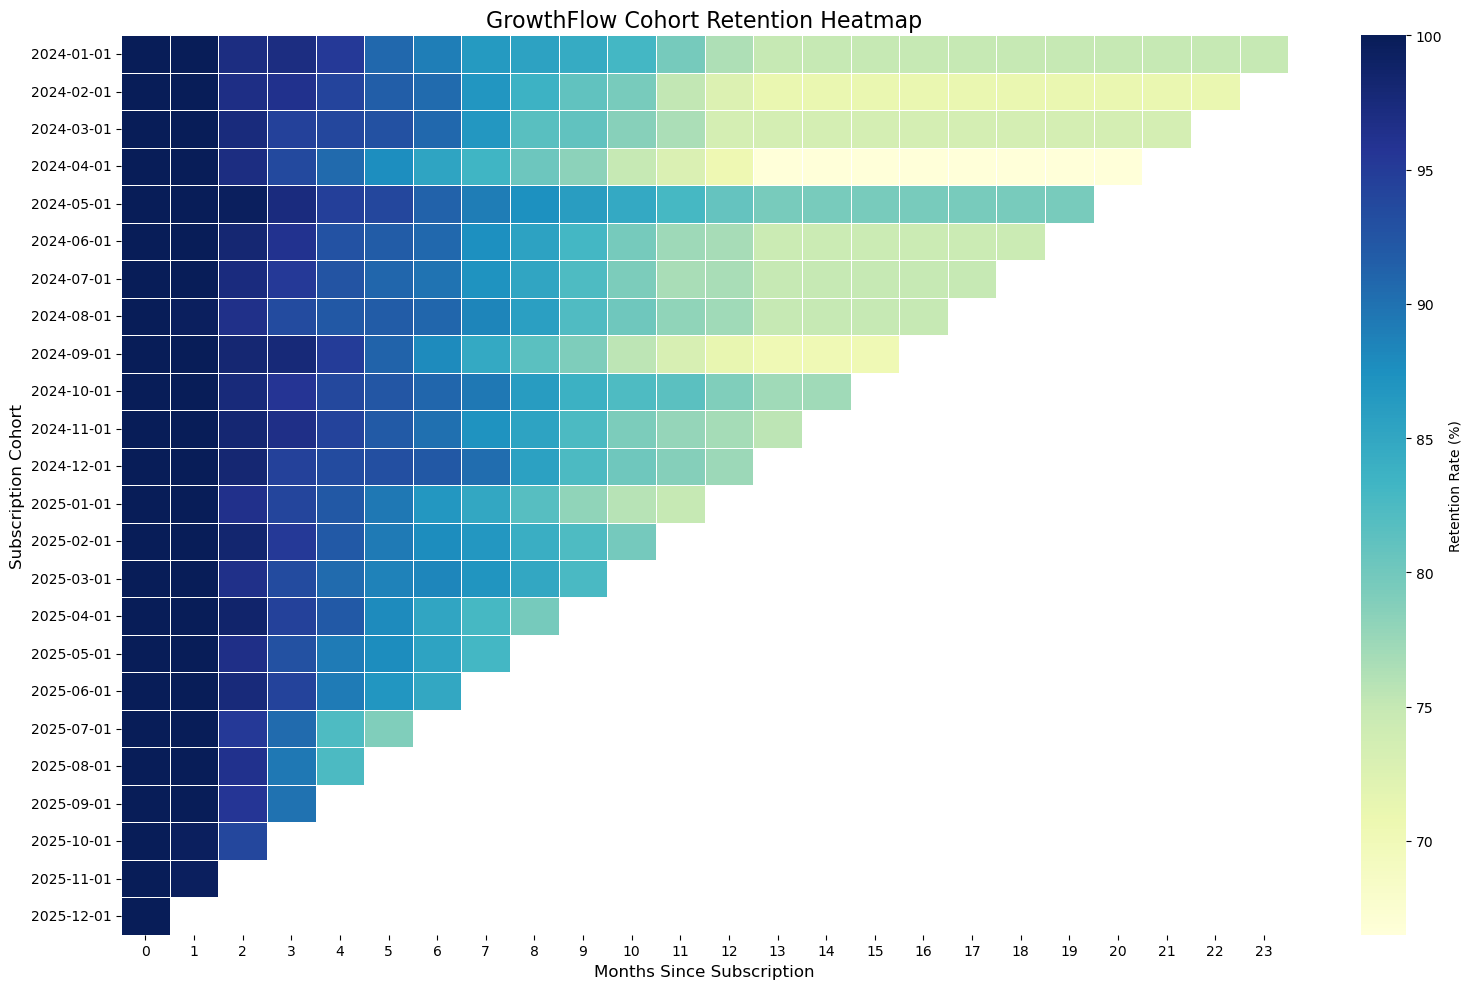

In [83]:
plt.figure(figsize=(16, 10))

sns.heatmap(
    retention_matrix,
    mask=retention_matrix.isna(),
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Retention Rate (%)"}
)

plt.title("GrowthFlow Cohort Retention Heatmap", fontsize=16)
plt.xlabel("Months Since Subscription", fontsize=12)
plt.ylabel("Subscription Cohort", fontsize=12)

plt.tight_layout()
plt.show()

## 6.6 Cohort Analysis Business Insights
### Objective

Interpret the cohort retention results and identify customer retention patterns across different subscription cohorts.

#### Business Insight

The cohort retention analysis shows that all customer cohorts begin with a 100% retention rate at Month 0, as expected. Retention gradually declines over subsequent months, indicating that some customers discontinue their subscriptions over time.

The earliest cohorts have the longest observation periods and exhibit a steady reduction in retained customers, while more recent cohorts maintain higher retention percentages because they have had less time to experience churn. Overall, GrowthFlow demonstrates relatively stable customer retention, with no evidence of abrupt or unusually high customer losses in the early months after subscription.

These insights provide a strong foundation for identifying customer churn patterns, evaluating long-term customer loyalty, and designing targeted retention strategies.

## 6.7 Save the Retention Matrix

In [84]:
retention_matrix.to_csv(
    "growthflow_cohort_retention_matrix.csv"
)

print("Cohort retention matrix exported successfully.")

Cohort retention matrix exported successfully.
